<font color=#009afa size=50>DAT-6002 - Fundamentals of Artificial Intelligence</font><br>
<font size=50>WRIT1 Part 2 - Neural Networks</font><br>
<font size=20 color=#00c382>From Scratch MLP - Bank Data</font><br>

|**Assessment Code:** |WRIT1|
|---|---|
|**Author:**|Tom Rowan|
|**Course:**|DAT6002_S2_25|
|**Course Tutor:**|Imtiaz Hussain Khan, PhD|


**Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.**

https://archive.ics.uci.edu/dataset/222/bank+marketing

---

# Initialise Notebook

In [1]:
# Install Requirements Using Pip
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [2]:
# Standard Libraries
import sys
import time
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
#from matplotlib import colormaps
#import matplotlib.colors as mcolors
#from matplotlib.pyplot import figure
#import matplotlib.ticker as mticker
#import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests


# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [3]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [4]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow', newline=True):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
        
    # Newline - defaul to a newline
    nl=None if newline else ' '
    
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}', end=nl)

### Check for Internet Access

In [5]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [6]:
internet_required = False

In [7]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


---
# Load the Dataset

In [8]:
if online:
    # Fetch the dataset from the Internet
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')
else:
    # Load the dataset from local file
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')

In [9]:
# Full 45 feature model dataset
#
#  df = pd.read_csv('bank_full_scaled_20260322.csv', delimiter=',')

In [10]:
df.shape

(45211, 29)

In [11]:
df.sample(5)

,age,balance,housing,loan,campaign,previous,y,pdays_binned,month_numeric,education_numeric,...,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown
44943,-0.088167,-0.447419,0.0,0.0,-0.569351,-0.251940,0.0,0.00,0.818182,1.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
19741,-0.653211,-0.265137,1.0,0.0,4.918084,-0.251940,0.0,0.00,0.636364,1.000000,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
16498,-1.406602,0.326376,1.0,0.0,1.044601,-0.251940,0.0,0.00,0.545455,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
33904,0.194355,-0.355786,1.0,0.0,-0.569351,0.182198,0.0,0.75,0.272727,1.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
6755,-0.559037,-0.383703,1.0,0.0,-0.569351,-0.251940,0.0,0.00,0.363636,0.333333,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


### Pre-MLP Processing

Now it is necessary to split the input dataset into two parts - testing and training data

In [12]:
# Split data frame into 80/20
df_train = df.sample(frac = 0.8, random_state = 67)
# Creating dataframe with rest of the 20% values
df_test = df.drop(df_train.index)

Check that the train and testing datasets are suitably representative of the target variable 'y':

In [13]:

# Print the percentage distribution of the target variable 'y'
print ((df_train['y'].value_counts(normalize=True).round(4) * 100))

# Print the percentage distribution of the target variable 'y'
print ((df_test['y'].value_counts(normalize=True).round(4) * 100))

y
0.0    88.42
1.0    11.58
Name: proportion, dtype: float64
y
0.0    87.83
1.0    12.17
Name: proportion, dtype: float64


In [14]:
print_output("df_train shape", df_train.shape)
print_output("df_test shape", df_test.shape)

df_train shape: (36169, 29)
df_test shape: (9042, 29)


In [15]:
# Split datasets into X (features) and y (labels)
df_X_train = df_train.drop(columns='y')
df_y_train = df_train['y']

df_X_test = df_test.drop(columns='y')
df_y_test = df_test['y']

In [16]:
df_X_train.columns

Index(['age', 'balance', 'housing', 'loan', 'campaign', 'previous',
       'pdays_binned', 'month_numeric', 'education_numeric',
       'poutcome_numeric', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown'],
      dtype='str')

# Neural Network

"Construct a three-layer feedforward neural network consisting of N input neurons, 10 hidden neurons, and M output neuron(s)."

In a neural network, the forward pass consists of two main operations per layer:

    Linear Transformation: Z=X⋅W+b

    Activation Function: A=σ(Z)

For a binary classification task like this, the Sigmoid function is the standard choice for the output layer because it squashes any input into a value between 0 and 1, which we can interpret as a probability.  (citation)

## MLP Class 

In [17]:
class MLP_From_Scratch:

    # Constructor
    def __init__(self, X_train, y_train, X_test, y_test, **kwargs):

        # Handle Arguments
        _random_seed = kwargs.get('random_seed', 67)
        self.debug = kwargs.get('debug', False)

        _validation_split = kwargs.get('validation_split', 0.2)    # Default to 20% of the training data

        # Split off validation dataset from the training data
        val_X = X_train.sample(frac=_validation_split, random_state=_random_seed)
        val_y = y_train.loc[val_X.index]

        # Convert provided data to numpy arrays
        self.X_np_train = X_train.to_numpy()
        self.y_np_train = y_train.to_numpy().reshape(-1,1)

        self.X_np_val = val_X.to_numpy()
        self.y_np_val = val_y.to_numpy().reshape(-1,1)

        self.X_np_test = X_test.to_numpy()
        self.y_np_test = y_test.to_numpy().reshape(-1,1)

        # Additional Model Parameters
        _act_func = kwargs.get('act_func', 'sigmoid')
        _no_hidden_neurons = kwargs.get('no_hidden_neurons', 10)    # Defaults to 10 hidden neurons, per assessment specification
        _no_output_neurons = kwargs.get('no_output_neurons', 1)
        self.output_threshold = kwargs.get('output_threshold', 0.5)

        # Define Model Parameters
        self.no_input_neurons  = self.X_np_train.shape[1]    # Set dynamically based on the input dataset
        self.no_hidden_neurons = _no_hidden_neurons          
        self.no_output_neurons = _no_output_neurons
        self.learning_rate = 0.03          

        # Initialize Weights with small random numbers
        # 
        #   input_neurons --> weights_0 --> hidden_neurons --> weights_1 --> output_neurons
        #                                   biases_1                         biases_2
        #
        np.random.seed(_random_seed)

        self.weights_0 = np.random.randn(self.no_input_neurons, self.no_hidden_neurons) 
        self.weights_1 = np.random.randn(self.no_hidden_neurons, self.no_output_neurons)

        self.biases_1 = np.zeros((1, self.no_hidden_neurons))
        self.biases_2 = np.zeros((1, self.no_output_neurons))


        if self.debug:
            print_output("No Input Layer Neurons", self.no_input_neurons, colour='blue')
            print_output("No Input to Hidden Weights", self.weights_0.size)

            print_output("No Hidden Layer Neurons", self.no_hidden_neurons, colour='blue')
            print_output("No Hidden Layer Biases", self.biases_1.size, colour='blue')

            print_output("No Hidden to Output Weights", self.weights_1.size)

            print_output("No Output Layer Neurons", self.no_output_neurons, colour='blue')
            print_output("No Output Layer Biases", self.biases_2.size, colour='blue')


    #
    # ***** Activation Functions 
    #

    def _relu(self, x):
        return np.maximum(0, x)

    def _relu_derivative(self, x):
        return (x > 0).astype(float)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _sigmoid_derivative(self, x):
        return x * (1 - x)

    # Generic version to allow replacement
    # TO DO - Add softmax for the output layer and allow selection of activation function for each layer
    # add to report.,..
    
    def _act_func(self, x):
        return self._sigmoid(x)

    def _act_func_deriv(self, x):
        return self._sigmoid_derivative(x)
    
    #
    # ***** MLP Process Functions 
    #

    def _feed_forward(self, X):
        sum_synapse_0 = np.dot(X, self.weights_0) + self.biases_1
        hidden_layer = self._act_func(sum_synapse_0)
        
        sum_synapse_1 = np.dot(hidden_layer, self.weights_1) + self.biases_2
        output_layer = self._act_func(sum_synapse_1)
        
        # Return everything
        return X, hidden_layer, output_layer
    

    def _back_propagation(self, output_layer):
        error_output_layer = self.y_np_train - output_layer
        average_error = np.mean(abs(error_output_layer))
        
        derivative_output = self._act_func_deriv(output_layer)
        delta_output = error_output_layer * derivative_output

        return delta_output, average_error
    
    
    def _back_propagation_hidden(self, delta_output, hidden_layer):
    
        # Transpose the numpy array
        weights_1T = self.weights_1.T
        
        delta_output_weight = delta_output.dot(weights_1T)
        delta_hidden_layer = delta_output_weight * self._act_func_deriv(hidden_layer)
        
        hidden_layerT = hidden_layer.T
        input_x_delta1 = hidden_layerT.dot(delta_output)

        return delta_hidden_layer, input_x_delta1
    

    def _weight_bias_update(self, input_layer, input_x_delta1, delta_hidden_layer, delta_output):

        m = input_layer.shape[0]                                                          # Batch size to normalise the gradient
        
        self.weights_1 = self.weights_1 + (input_x_delta1 / m * self.learning_rate)       # Divide by m to compute the average gradient
        
        input_layerT = input_layer.T
        input_x_delta0 = input_layerT.dot(delta_hidden_layer)
        self.weights_0 = self.weights_0 + (input_x_delta0 / m * self.learning_rate)                                                            

        self.biases_1 = self.biases_1 + np.sum(delta_hidden_layer, axis=0, keepdims=True) / m * self.learning_rate
        self.biases_2 = self.biases_2 + np.sum(delta_output, axis=0, keepdims=True) / m * self.learning_rate 

    # Run the feed forward process and return the predicted classes (0 or 1) based on the output threshold
    def _get_predictions(self, X):
        _, _, output = self._feed_forward(X)
        return (output > self.output_threshold).astype(int)

    # Calculate accuracy by comparing predicted classes to true labels
    def _calculate_accuracy(self, X, y):
        y_pred = self._get_predictions(X)
        return np.mean(y_pred == y) * 100
    

    def _get_confusion_matrix(self, X_data=None, y_data=None):
            
        # Default to the test set if no specific data is provided
        if X_data is None:
            X_data = self.X_np_test
            y_data = self.y_np_test

        y_pred = self._get_predictions(X_data)
        
        # Flatten the arrays to ensure they are 1D to compare
        y_true = y_data.flatten()
        y_pred = y_pred.flatten()
        
        # Calculate True Positives, True Negatives, False Positives, and False Negatives
        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        accuracy = (tp + tn) / len(y_true)
        
        return np.array([[tn, fp], [fn, tp]]), accuracy

    #
    # ***** Public Functions 
    #

    # Allows updating of model parameters (e.g. learning rate, output threshold) without needing to retrain the model from scratch
    def set_model_parameters(self, **kwargs):
        self.learning_rate = kwargs.get('learning_rate', self.learning_rate)
        self.output_threshold = kwargs.get('output_threshold', self.output_threshold)

    def train_network_old (self, epochs, **kwargs):
        
        # Set up parameters
        self.learning_rate = kwargs.get('learning_rate', self.learning_rate)
        self.error = []

        # Loop through the training epochs
        for epoch in range(epochs):
            # Run the feed forward process to get the output layer values
            input_layer, hidden_layer, output_layer = self._feed_forward(self.X_np_train)

            # Run the back propagation process to get the output layer deltas and average error
            delta_output, average_error = self._back_propagation(output_layer)    

            if epoch % 100 == 0:
                self.error.append(average_error)
                if self.debug:
                    print_output('Epoch', str(epoch + 1) + " ", newline=False)
                    print_output('Error', str(average_error))
            
            # Run the back propagation process for the hidden layer to get the hidden layer deltas and inputXdelta for weight updates
            delta_hidden_layer, input_x_delta1 = self._back_propagation_hidden(delta_output, hidden_layer)                

            # Reuse the same weight bias update method for both hidden and output layer updates
            self._weight_bias_update(input_layer, input_x_delta1, delta_hidden_layer, delta_output)


    def train_network(self, epochs, **kwargs):

        # Set up parameters
        self.learning_rate = kwargs.get('learning_rate', self.learning_rate)
        self.train_error_history = []
        self.valid_error_history = [] # To track validation

        for epoch in range(epochs):

            # Forward
            input_layer, hidden_layer, output_layer = self._feed_forward(self.X_np_train)
            
            # Back prop (Output)
            delta_output, train_error = self._back_propagation(output_layer)
            
            # Back prop (Hidden)
            delta_hidden_layer, input_x_delta1 = self._back_propagation_hidden(delta_output, hidden_layer)
            
            # Update Weights
            self._weight_bias_update(input_layer, input_x_delta1, delta_hidden_layer, delta_output)


            if epoch % 100 == 0:
                # We use the SAME feed_forward method but with TEST data
                _, _, test_output = self._feed_forward(self.X_np_test)
                
                # Calculate validation error (Mean Absolute Error)
                valid_error = np.mean(np.abs(self.y_np_test - test_output))
                
                self.train_error_history.append(train_error)
                self.valid_error_history.append(valid_error)

                if self.debug:
                    print(f"Epoch {epoch}: Train Error: {train_error:.4f} | Valid Error: {valid_error:.4f}")

                    
    # Evaluate the model on the provided dataset and return accuracy
    # Allows specifying a custom output threshold for prediction
    # Allows proving a custom dataset instead of the default test set
    def evaluate(self, X_data=None, y_data=None):
            
        # Default to the test set if no specific data is provided
        if X_data is None:
            X_data = self.X_np_test
            y_data = self.y_np_test
        
        self.accuracy = self._calculate_accuracy(X_data, y_data)
        return self.accuracy 
    

    def plot_error(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.train_error_history, label='Training Error')
        plt.plot(self.valid_error_history, label='Validation Error', linestyle='--')
        plt.xlabel('Epochs (x100)')
        plt.ylabel('Mean Absolute Error')
        plt.title('Training vs Validation Error')
        plt.legend()
        plt.show()



    

    def plot_confusion_matrix(self):

        matrix, accuracy = self._get_confusion_matrix()
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(matrix, cmap='Blues')

        # Add colorbar
        plt.colorbar(im)

        # Set labels
        classes = ['No (0)', 'Yes (1)']
        ax.set_xticks(np.arange(len(classes)))
        ax.set_yticks(np.arange(len(classes)))
        ax.set_xticklabels(classes)
        ax.set_yticklabels(classes)

        # Rotate the tick labels and set their alignment.
        plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

        # Loop over data dimensions and create text annotations.
        for i in range(2):
            for j in range(2):
                text = ax.text(j, i, matrix[i, j],
                            ha="center", va="center", color="black", fontsize=14)

        ax.set_title("Confusion Matrix Heatmap")
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        plt.tight_layout()
        plt.show()


    # Text Representation
    def print_confusion_matrix(self):
        matrix, self.accuracy = self._get_confusion_matrix() 
        print(f"{'':>15} | {'Predicted No':>12} | {'Predicted Yes':>12} |")
        print("-" * 48)
        print(f"{'Actual No':>15} | {matrix[0][0]:>12} | {matrix[0][1]:>12} |")
        print(f"{'Actual Yes':>15} | {matrix[1][0]:>12} | {matrix[1][1]:>12} |")
        print("-" * 48)
        print (f"Accuracy: {self.accuracy:.2f}%")


    # Export the model weights and biases to a JSON file
    def save_weights(self, filename):
        weights_data = {
            'weights_0': self.weights_0.tolist(),
            'weights_1': self.weights_1.tolist(),
            'biases_1': self.biases_1.tolist(),
            'biases_2': self.biases_2.tolist()
        }
        with open(filename, 'w') as f:
            json.dump(weights_data, f, indent=4)

    # Load the model weights and biases from a JSON file
    def load_weights(self, filename):
        with open(filename, 'r') as f:
            weights_data = json.load(f)
            self.weights_0 = np.array(weights_data['weights_0'])
            self.weights_1 = np.array(weights_data['weights_1'])
            self.biases_1 = np.array(weights_data['biases_1'])
            self.biases_2 = np.array(weights_data['biases_2'])

    def get_report(self, X_data, y_data):
        # Get the confusion matrix components
        matrix, accuracy = self._get_confusion_matrix(X_data, y_data)
        tn, fp = matrix[0]
        fn, tp = matrix[1]

        # Calculate metrics (with safety for division by zero)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        print(f"--- Performance Report (Threshold: {self.output_threshold}) ---")
        print(f"Accuracy:  {accuracy:.4f}")
        print(f"Precision: {precision:.4f} (Reliability of 'Yes' predictions)")
        print(f"Recall:    {recall:.4f} (Ability to find 'Yes' customers)")
        print(f"F1-Score:  {f1:.4f} (Overall balance)")
        print("---------------------------------------------------------")
        
        return {"acc": accuracy, "prec": precision, "rec": recall, "f1": f1}
        

This is a binary classification problem, which implies 1 output neuron

No Input Layer Neurons: 28
No Input to Hidden Weights: 280
No Hidden Layer Neurons: 10
No Hidden Layer Biases: 10
No Hidden to Output Weights: 10
No Output Layer Neurons: 1
No Output Layer Biases: 1
Epoch 0: Train Error: 0.6574 | Valid Error: 0.6522
Epoch 100: Train Error: 0.4541 | Valid Error: 0.4521
Epoch 200: Train Error: 0.3480 | Valid Error: 0.3487
Epoch 300: Train Error: 0.2979 | Valid Error: 0.2998
Epoch 400: Train Error: 0.2698 | Valid Error: 0.2724
Epoch 500: Train Error: 0.2520 | Valid Error: 0.2549
Epoch 600: Train Error: 0.2396 | Valid Error: 0.2428
Epoch 700: Train Error: 0.2305 | Valid Error: 0.2339
Epoch 800: Train Error: 0.2236 | Valid Error: 0.2271
Epoch 900: Train Error: 0.2181 | Valid Error: 0.2218
Epoch 1000: Train Error: 0.2136 | Valid Error: 0.2174
Epoch 1100: Train Error: 0.2100 | Valid Error: 0.2138
Epoch 1200: Train Error: 0.2069 | Valid Error: 0.2108
Epoch 1300: Train Error: 0.2043 | Valid Error: 0.2083
Epoch 1400: Train Error: 0.2021 | Valid Error: 0.2061
Epo

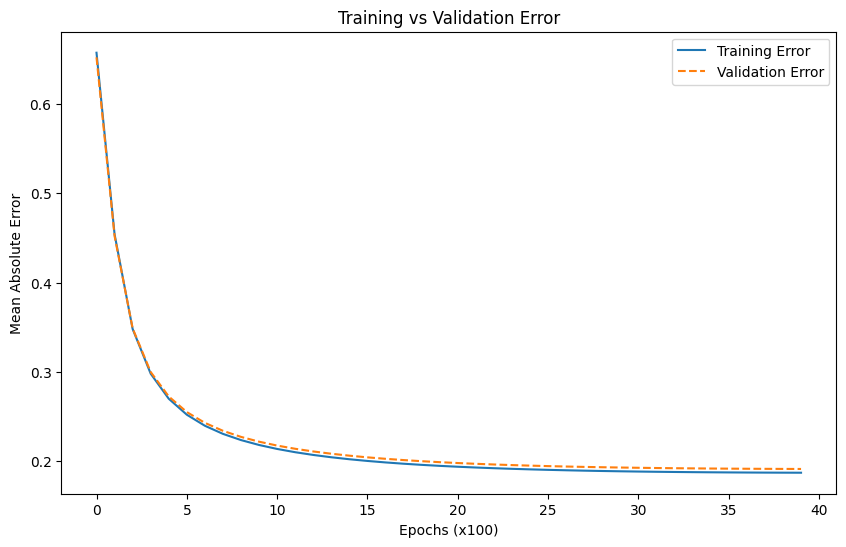

In [18]:
mlp = MLP_From_Scratch(df_X_train, df_y_train, df_X_test, df_y_test, debug=True, learning_rate=0.05, output_threshold=0.5)
mlp.train_network(epochs=4000)
mlp.plot_error()


Save out the weights for later use

In [19]:
mlp.save_weights('mlp_weights.json')

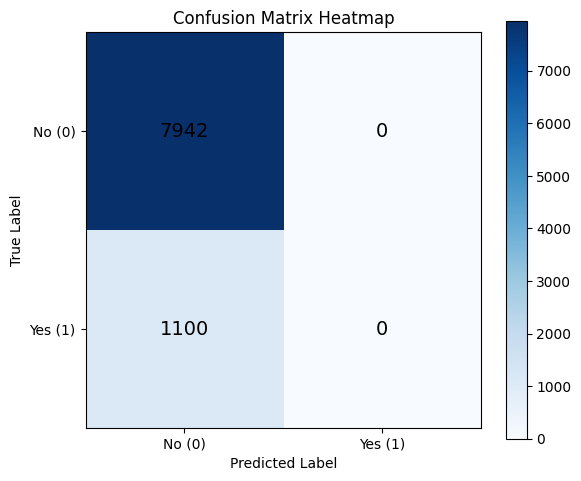

In [20]:
mlp.set_model_parameters(output_threshold=0.50)
mlp.plot_confusion_matrix()

Exploring different output thresholds as a 'solution' to model bias.

In [21]:
results_list = []

for threshold in np.arange(0, 1, 0.1):
    threshold=threshold.round(1)
    print_output("\nTesting with output bias threshold", threshold, colour='cyan')
    
    # Dynamically update the model's output threshold and re-evaluate without needing to retrain
    mlp.set_model_parameters(output_threshold=threshold)
    matrix, accuracy = mlp._get_confusion_matrix()
    
    # Split apart the confusion matrix values for easier access
    tn, fp = matrix[0]
    fn, tp = matrix[1]
    
    # 3. Calculate Precision and Recall 
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0          # handle division by zero
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    results_list.append({
        'Threshold': threshold,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall
    })

    mlp.print_confusion_matrix()
    #mlp.plot_confusion_matrix()

# Convert to DataFrame for plotting
df_metrics = pd.DataFrame(results_list)


Testing with output bias threshold: 0.0
                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |            0 |         7942 |
     Actual Yes |            0 |         1100 |
------------------------------------------------
Accuracy: 0.12%

Testing with output bias threshold: 0.1
                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |         5403 |         2539 |
     Actual Yes |          720 |          380 |
------------------------------------------------
Accuracy: 0.64%

Testing with output bias threshold: 0.2
                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |         7419 |          523 |
     Actual Yes |         1006 |           94 |
------------------------------------------------
Accuracy: 0.83%

Testing with output bias threshold: 0.3
                | Predicted No | Predicted Yes |
----------

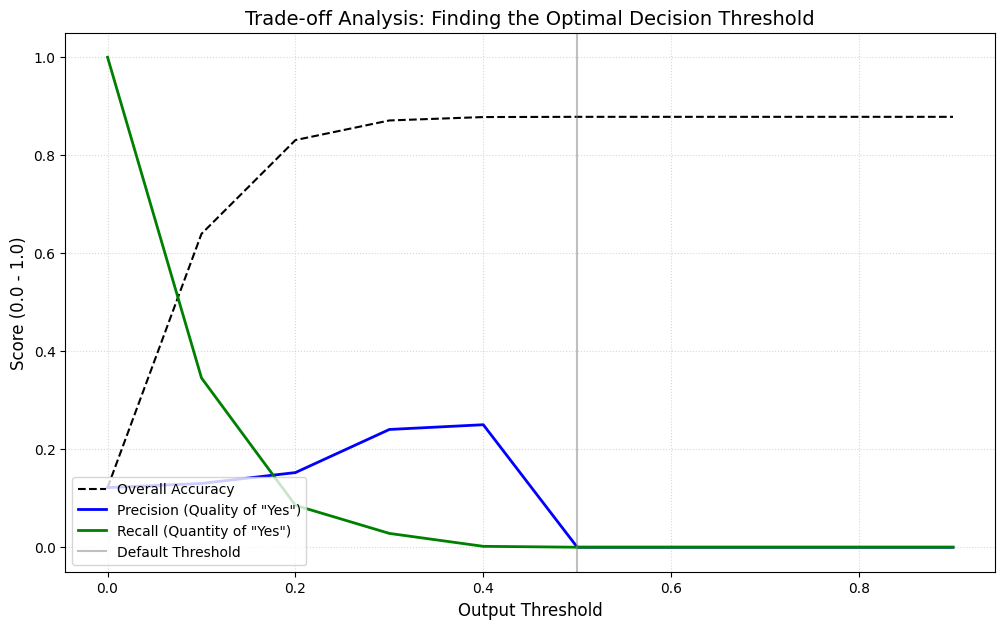

In [22]:
plt.figure(figsize=(12, 7))

# Plot the three main metrics
plt.plot(df_metrics['Threshold'], df_metrics['Accuracy'], label='Overall Accuracy', color='black', linestyle='--')
plt.plot(df_metrics['Threshold'], df_metrics['Precision'], label='Precision (Quality of "Yes")', color='blue', linewidth=2)
plt.plot(df_metrics['Threshold'], df_metrics['Recall'], label='Recall (Quantity of "Yes")', color='green', linewidth=2)

# Mark the standard 0.5 threshold
plt.axvline(x=0.5, color='gray', alpha=0.5, label='Default Threshold')

plt.title('Trade-off Analysis: Finding the Optimal Decision Threshold', fontsize=14)
plt.xlabel('Output Threshold', fontsize=12)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, which='both', linestyle=':', alpha=0.5)

plt.show()

In [23]:
mlp.get_report(mlp.X_np_test, mlp.y_np_test)

--- Performance Report (Threshold: 0.9) ---
Accuracy:  0.8783
Precision: 0.0000 (Reliability of 'Yes' predictions)
Recall:    0.0000 (Ability to find 'Yes' customers)
F1-Score:  0.0000 (Overall balance)
---------------------------------------------------------


{'acc': np.float64(0.878345498783455),
 'prec': 0,
 'rec': np.float64(0.0),
 'f1': 0}

Based on the crossing point on the graph above, setting the output_threshold to 0.19:

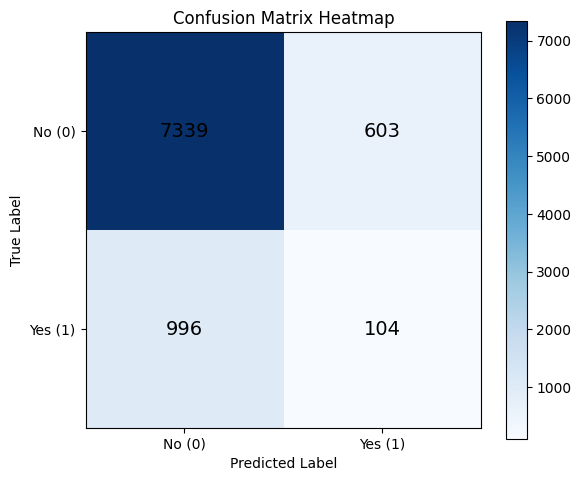

In [24]:
mlp.set_model_parameters(output_threshold=0.19)
mlp.plot_confusion_matrix()

### Model Evaluation Metrics

| Metric | Mathematical Formula | Description | What it tells the Bank |
| :--- | :---: | :--- | :--- |
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | The proportion of total predictions that were correct. | Overall success rate  |
| **Precision** | $\frac{TP}{TP + FP}$ | The proportion of positive identifications that were actually correct. | "When we call someone a potential customer, how often are we right?" |
| **Recall** | $\frac{TP}{TP + FN}$ | The proportion of actual positives that were identified correctly. | Out of everyone who would have said 'Yes', how many did we actually find? |
| **F1-Score** | $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$ | The mean of Precision and Recall. | The "balanced" score that punishes models for ignoring the minority class. |

In [25]:
sys.exit('Stopping notebook run here.')   

SystemExit: Stopping notebook run here.

Notes for report:

Why use a Validation set instead of just the Test set?

If you use your Test set to decide when to stop training or what learning rate to use, you are technically "leaking" information. You might end up with a model that performs great on that specific Test set but fails in the real world. By using a Validation set, you keep the Test set completely "unseen" until the very final moment of your project.


Three Crucial "Scratch" Tips for your Assessment:

1. The "Sign" of your Update: In your _weight_bias_update, you are using:
self.weights_1 = self.weights_1 + (input_x_delta1 ...)
Normally, Gradient Descent subtracts the gradient. However, because you calculated error_output_layer as Target - Output (which is the negative gradient), using + is mathematically correct here. Just keep an eye on that!

2. Accuracy vs. Error:
Error (MAE) is great for the math, but your assessment likely wants to see Accuracy. You can add a quick method to calculate how many predictions were correct:

To know how "wrong" the network is, we use Binary Cross-Entropy Loss (also called Log Loss). This is much more effective for classification than Mean Squared Error.
Loss=−m1​∑[y⋅log(y^​)+(1−y)⋅log(1−y^​)]

In [ ]:
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    # Adding a tiny epsilon (1e-15) prevents log(0) which would result in NaN
    loss = -1/m * np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))
    return loss

---